<a href="https://colab.research.google.com/github/joury7766-spec/ETL-gdp-pipeline/blob/main/big_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install rasterio

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Riyadh_LST.tif to Riyadh_LST.tif


In [ ]:
import rasterio

file_path = "Riyadh_LST.tif"

with rasterio.open(file_path) as src:
    print("Opened successfully ✅")
    print("Height:", src.height)
    print("Width:", src.width)
    print("Bands:", src.count)

Opened successfully ✅
Height: 2973
Width: 3711
Bands: 1


In [ ]:
import numpy as np

with rasterio.open(file_path) as src:
    band = src.read(1)

print("Number of pixels:", band.size)

Number of pixels: 11032803


In [ ]:
print(band[:5,:5])


[[        nan         nan         nan         nan         nan]
 [        nan         nan         nan         nan         nan]
 [        nan         nan         nan         nan         nan]
 [41.64110337 41.62318039 41.57956819 41.50423113 41.32438487]
 [41.57109886 41.55703738 41.51373886 41.43667116 41.25057295]]


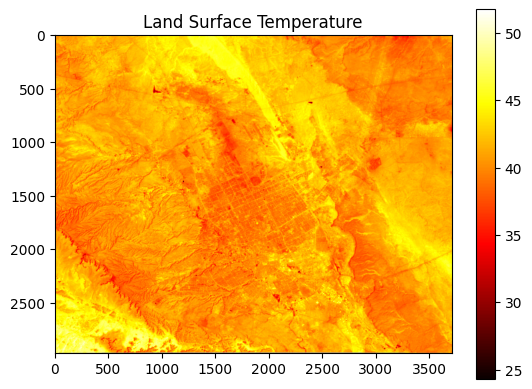

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(band, cmap='hot')
plt.colorbar()
plt.title("Land Surface Temperature")
plt.show()

In [ ]:
print("Min:", band.min())
print("Max:", band.max())
print("Mean:", band.mean())

Min: nan
Max: nan
Mean: nan


# تحويل صورة الحرارة إلى Dataset

In [ ]:
import pandas as pd
import rasterio
import numpy as np

file_path = "Riyadh_LST.tif"

with rasterio.open(file_path) as src:
    band = src.read(1)
    transform = src.transform

rows, cols = np.where(~np.isnan(band))

lats = []
lons = []
temps = []

for r, c in zip(rows, cols):
    lon, lat = rasterio.transform.xy(transform, r, c)
    lats.append(lat)
    lons.append(lon)
    temps.append(band[r, c])

df = pd.DataFrame({
    "latitude": lats,
    "longitude": lons,
    "LST": temps
})

df.head()

,latitude,longitude,LST
0,25.200843,46.562601,45.872850
1,25.200843,46.562870,45.872850
2,25.200843,46.563140,45.849778
3,25.200843,46.563409,45.803657
4,25.200843,46.563679,45.762284


# : تقليل حجم البيانات

ناخذ عينه بس لان البيانات 11 مليون

In [ ]:
df_sample = df.sample(50000)
df_sample.head()

,latitude,longitude,LST
2439216,25.023515,46.726992,44.569389
376364,25.173354,46.852038,39.646420
2757896,25.000339,46.601408,38.542048
7682772,24.642720,46.703546,39.996188
8938015,24.551630,46.952829,39.826333


# تحليل البيانات (EDA)
توزيع الحرارة

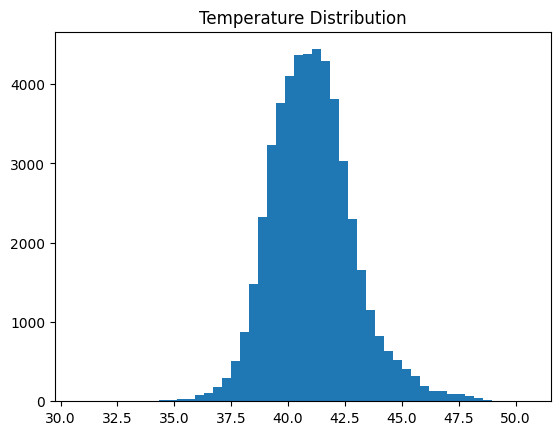

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df_sample["LST"], bins=50)
plt.title("Temperature Distribution")
plt.show()

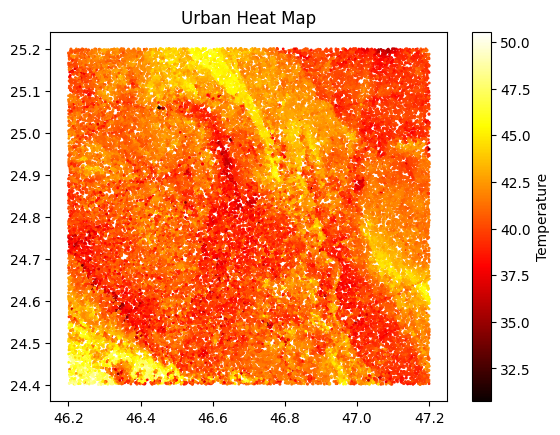

In [ ]:
plt.scatter(
    df_sample["longitude"],
    df_sample["latitude"],
    c=df_sample["LST"],
    cmap="hot",
    s=1
)
plt.colorbar(label="Temperature")
plt.title("Urban Heat Map")
plt.show()

# إضافة NDVI

البيانات الجديده

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Riyadh_NDVI.tif to Riyadh_NDVI.tif
Saving Riyadh_Urban.tif to Riyadh_Urban.tif


In [ ]:
import rasterio
import numpy as np

lst = rasterio.open("Riyadh_LST.tif").read(1)
ndvi = rasterio.open("Riyadh_NDVI.tif").read(1)
urban = rasterio.open("Riyadh_Urban.tif").read(1)

In [ ]:
import rasterio

with rasterio.open("Riyadh_LST.tif") as src:
    print("LST shape:", src.read(1).shape)

with rasterio.open("Riyadh_NDVI.tif") as src:
    print("NDVI shape:", src.read(1).shape)

with rasterio.open("Riyadh_Urban.tif") as src:
    print("Urban shape:", src.read(1).shape)

LST shape: (2973, 3711)
NDVI shape: (2973, 3711)
Urban shape: (10017, 10956)


In [ ]:
import rasterio

files = ["Riyadh_LST.tif", "Riyadh_NDVI.tif", "Riyadh_Urban.tif"]

for f in files:
    with rasterio.open(f) as src:
        print("FILE:", f)
        print(" shape:", src.read(1).shape)
        print(" crs:", src.crs)
        print(" transform:", src.transform)
        print("-" * 40)

FILE: Riyadh_LST.tif
 shape: (2973, 3711)
 crs: EPSG:4326
 transform: | 0.00, 0.00, 46.20|
| 0.00,-0.00, 25.20|
| 0.00, 0.00, 1.00|
----------------------------------------
FILE: Riyadh_NDVI.tif
 shape: (2973, 3711)
 crs: EPSG:4326
 transform: | 0.00, 0.00, 46.20|
| 0.00,-0.00, 25.20|
| 0.00, 0.00, 1.00|
----------------------------------------
FILE: Riyadh_Urban.tif
 shape: (10017, 10956)
 crs: EPSG:4326
 transform: | 0.00, 0.00, 46.18|
| 0.00,-0.00, 25.16|
| 0.00, 0.00, 1.00|
----------------------------------------


In [ ]:
import rasterio
from rasterio.warp import reproject, Resampling
import numpy as np

# نفتح LST كمرجع
with rasterio.open("Riyadh_LST.tif") as ref:
    lst = ref.read(1)
    ref_transform = ref.transform
    ref_crs = ref.crs
    ref_shape = lst.shape

# فتح Urban
with rasterio.open("Riyadh_Urban.tif") as src:
    urban_src = src.read(1)

    urban_resampled = np.empty(ref_shape, dtype=np.float32)

    reproject(
        source=urban_src,
        destination=urban_resampled,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=ref_transform,
        dst_crs=ref_crs,
        resampling=Resampling.nearest
    )

print("Urban new shape:", urban_resampled.shape)

Urban new shape: (2973, 3711)


In [ ]:
with rasterio.open("Riyadh_NDVI.tif") as src:
    ndvi = src.read(1)

# تنظيف البيانات

In [ ]:
mask = (~np.isnan(lst)) & (~np.isnan(ndvi)) & (~np.isnan(urban_resampled))

lst_clean = lst[mask]
ndvi_clean = ndvi[mask]
urban_clean = urban_resampled[mask]

In [ ]:
import pandas as pd

df = pd.DataFrame({
    "LST": lst_clean,
    "NDVI": ndvi_clean,
    "Urban": urban_clean
})

df.head()

,LST,NDVI,Urban
0,45.872850,0.087340,0.0
1,45.872850,0.087340,0.0
2,45.849778,0.086091,0.0
3,45.803657,0.085258,0.0
4,45.762284,0.083815,0.0


## حفظ البيانات
بنات هنا دمجنا كل البيانات في

In [ ]:
df.to_csv("UHI_dataset.csv", index=False)